#2.1 Load merged data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import init_notebook_mode, show

os.chdir('C:/Users/lhcse/iCloudDrive/Learnings/Power-price-forecast')

df = pd.read_parquet('data/processed/merged_raw.parquet')

In [2]:
show(df)

Loading ITables v2.8.0 from the internet... (need help?)


#2.2 Price distribtuion

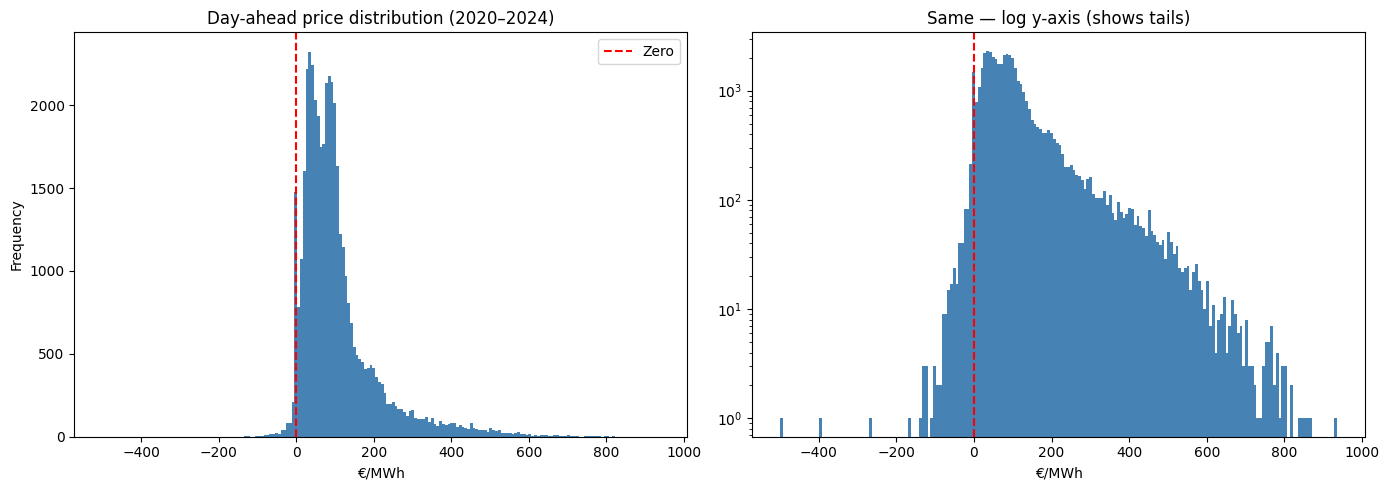

Negative price hours: 1,264
Share negative:       2.88%
99th percentile:      514.0 €/MWh
1st percentile:       -8.0 €/MWh


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_eur_mwh'].dropna(), bins=200,
             color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0].set_title('Day-ahead price distribution (2020–2024)')
axes[0].set_xlabel('€/MWh')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['price_eur_mwh'].dropna(), bins=200,
             color='steelblue', edgecolor='none', log=True)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Same — log y-axis (shows tails)')
axes[1].set_xlabel('€/MWh')

plt.tight_layout()
plt.savefig('results/figures/price_distribution.png', dpi=150)
plt.show()

print(f"Negative price hours: {(df['price_eur_mwh'] < 0).sum():,}")
print(f"Share negative:       {(df['price_eur_mwh'] < 0).mean():.2%}")
print(f"99th percentile:      {df['price_eur_mwh'].quantile(0.99):.1f} €/MWh")
print(f"1st percentile:       {df['price_eur_mwh'].quantile(0.01):.1f} €/MWh")

#2.3 Find when negative prices occur

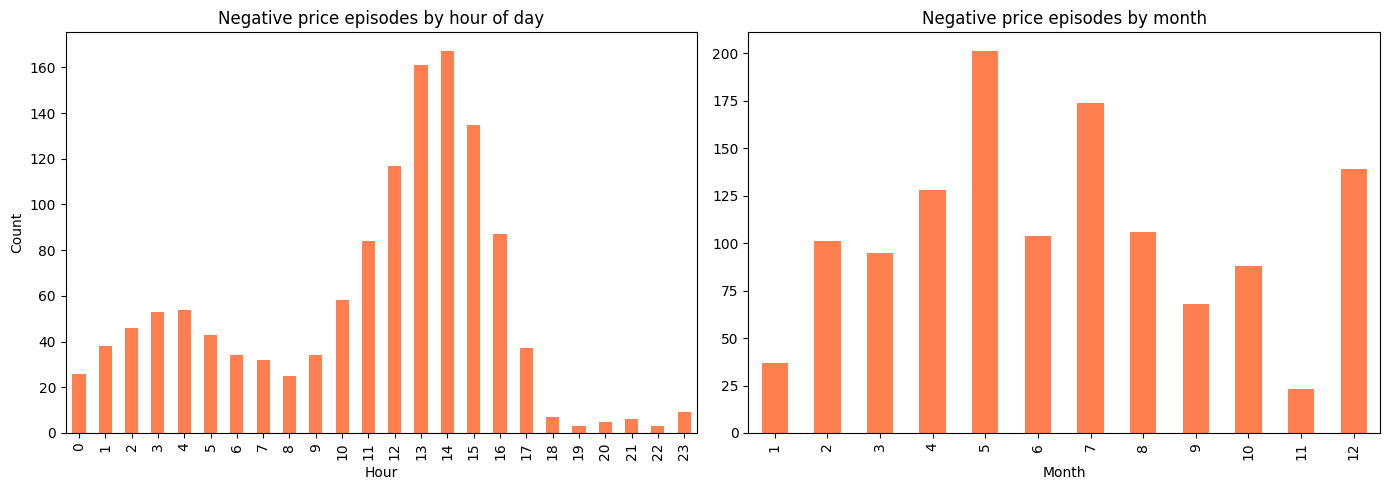

In [4]:
neg = df[df['price_eur_mwh'] < 0].copy()
neg['hour']  = neg.index.hour
neg['month'] = neg.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neg.groupby('hour').size().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Negative price episodes by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

neg.groupby('month').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Negative price episodes by month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('results/figures/negative_price_timing.png', dpi=150)
plt.show()

#2.4 Price vs renewable generation

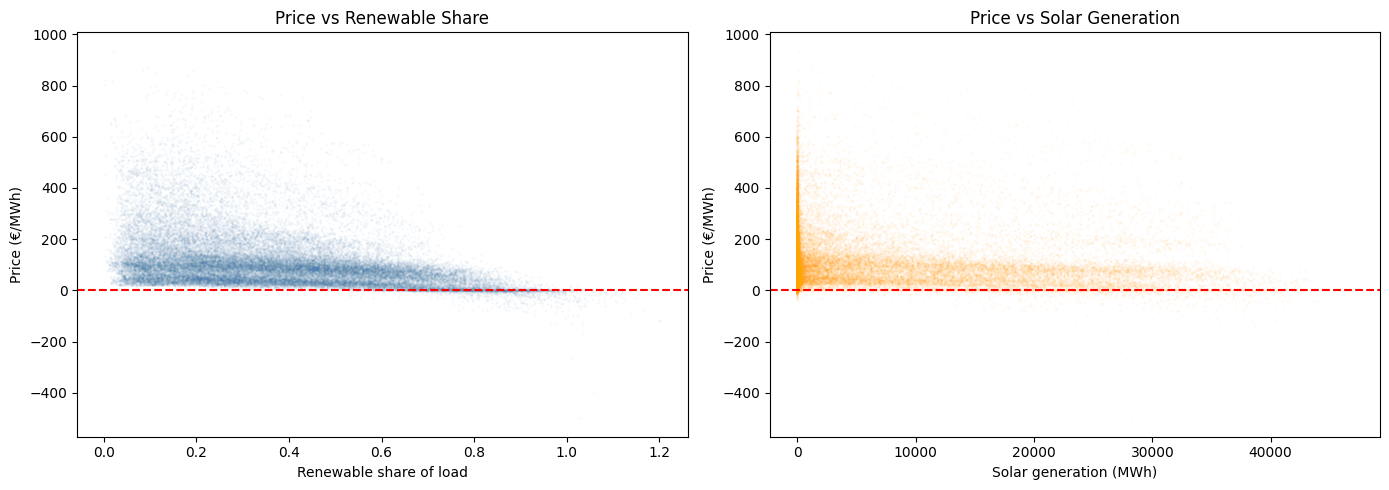

Correlation — price vs renewable share: -0.392


In [5]:
df['wind_total_gen_act'] = df['wind_on_gen_act'] + df['wind_off_gen_act']
df['ren_total_gen_act']  = df['wind_total_gen_act'] + df['solar_gen_act']
df['ren_share']          = df['ren_total_gen_act'] / df['load_act']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['ren_share'], df['price_eur_mwh'],
                alpha=0.03, s=1, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Renewable share of load')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_title('Price vs Renewable Share')

axes[1].scatter(df['solar_gen_act'], df['price_eur_mwh'],
                alpha=0.03, s=1, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Solar generation (MWh)')
axes[1].set_ylabel('Price (€/MWh)')
axes[1].set_title('Price vs Solar Generation')

plt.tight_layout()
plt.savefig('results/figures/price_vs_renewables.png', dpi=150)
plt.show()

print(f"Correlation — price vs renewable share: "
      f"{df['price_eur_mwh'].corr(df['ren_share']):.3f}")

#2.5 Price over time

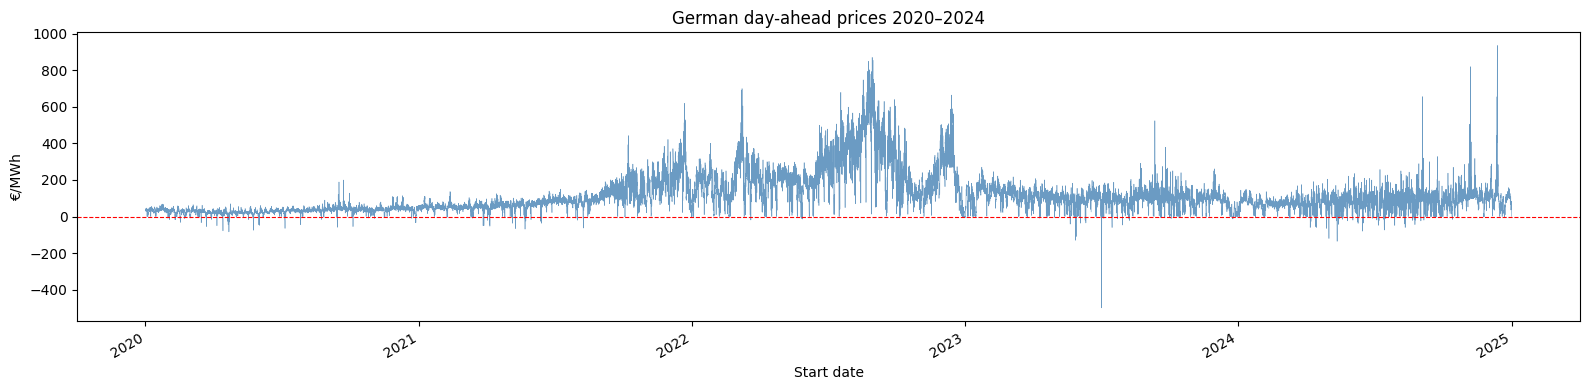

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
df['price_eur_mwh'].plot(ax=ax, linewidth=0.4, color='steelblue', alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('German day-ahead prices 2020–2024')
ax.set_ylabel('€/MWh')
plt.tight_layout()
plt.savefig('results/figures/price_timeseries.png', dpi=150)
plt.show()

#2.6 Prices relative to errors in production

In [7]:
#List collumn names
print(df.columns.tolist())

['price_eur_mwh', 'biomass_gen_act', 'hydro_gen_act', 'wind_off_gen_act', 'wind_on_gen_act', 'solar_gen_act', 'other_ren_gen_act', 'nuclear_gen_act', 'lignite_gen_act', 'hardcoal_gen_act', 'gas_gen_act', 'hydro_pump_gen_act', 'other_conv_gen_act', 'total_gen_fc', 'solar_wind_gen_fc', 'wind_off_gen_fc', 'wind_on_gen_fc', 'solar_gen_fc', 'other_gen_fc', 'load_act', 'load_incl_pump_act', 'hydro_pump_load_act', 'residual_load_act', 'load_fc', 'residual_load_fc', 'net_export', 'nl_export', 'nl_import', 'ch_export', 'ch_import', 'dk_export', 'dk_import', 'cz_export', 'cz_import', 'lu_export', 'lu_import', 'se_export', 'se_import', 'at_export', 'at_import', 'fr_export', 'fr_import', 'pl_export', 'pl_import', 'no_export', 'no_import', 'be_export', 'be_import', 'wind_total_gen_act', 'ren_total_gen_act', 'ren_share']


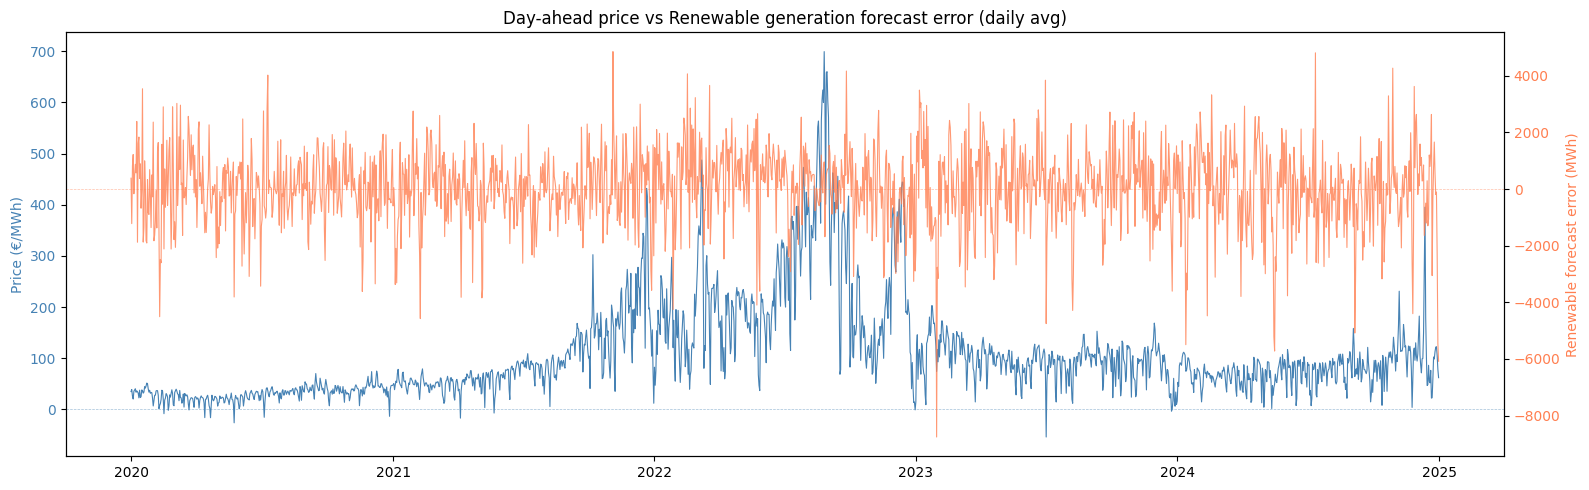

In [8]:
# Renewable forecast error
df['ren_gen_act'] = df['wind_on_gen_act'] + df['wind_off_gen_act'] + df['solar_gen_act']
df['ren_gen_fc']  = df['wind_on_gen_fc']  + df['wind_off_gen_fc']  + df['solar_gen_fc']
df['ren_gen_error'] = df['ren_gen_act'] - df['ren_gen_fc']

# Resample to daily — hourly is too noisy to see the pattern
daily = df[['price_eur_mwh', 'ren_gen_error']].resample('D').mean()

# Plot with dual y-axis
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(daily.index, daily['price_eur_mwh'],
         color='steelblue', linewidth=0.8, label='Price (€/MWh)')
ax1.set_ylabel('Price (€/MWh)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(0, color='steelblue', linestyle='--', linewidth=0.5, alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(daily.index, daily['ren_gen_error'],
         color='coral', linewidth=0.8, alpha=0.8, label='Renewable error (MWh)')
ax2.axhline(0, color='coral', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.set_ylabel('Renewable forecast error (MWh)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Day-ahead price vs Renewable generation forecast error (daily avg)')
fig.tight_layout()
plt.savefig('results/figures/price_vs_ren_error.png', dpi=150)
plt.show()